# QUEST 1
__Line chart with styles__

In [2]:
import pandas as pd
import sqlite3

database_path = "../data/checking-logs.sqlite"

In [3]:
try:
    connection = sqlite3.connect(database_path)
except Exception:
    print("Не удалось подключиться к СУБД :(")

In [4]:
query = """
select datetime from pageviews
where uid like 'user_%'
"""
df_pageviews = pd.io.sql.read_sql(query, connection)
df_pageviews["datetime"] = pd.to_datetime(df_pageviews["datetime"])

In [5]:
df_pageviews = df_pageviews.groupby(df_pageviews['datetime'].dt.date).agg({"datetime":"count"})
df_pageviews.rename(columns={"datetime":"views"}, inplace=True)
df_pageviews.head()

,views
datetime,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1


In [6]:
query = """
select timestamp from checker
where uid like 'user_%'
"""
df_checker = pd.io.sql.read_sql(query, connection)
df_checker["timestamp"] = pd.to_datetime(df_checker["timestamp"])
print(df_checker.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3207 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 25.2 KB
None


In [7]:
df_checker = df_checker.groupby(df_checker['timestamp'].dt.date).agg({"timestamp":"count"})
df_checker.rename(columns={"timestamp":"views"}, inplace=True)
df_checker.head()

,views
timestamp,
2020-04-17,23
2020-04-18,69
2020-04-19,33
2020-04-20,25
2020-04-21,25


In [8]:
df_checker.index.name = "daytime"
df_result = pd.merge(left=df_pageviews, right=df_checker, left_index=True, right_index=True, how="inner")
df_result.rename(columns={"views_x":"views", "views_y":"commits"}, inplace=True)
df_result.index.name = "date"
print(len(df_result))
display(df_result)


32


,views,commits
date,,
2020-04-17,1,23
2020-04-18,23,69
2020-04-19,15,33
2020-04-21,3,25
2020-04-22,1,28
2020-04-23,5,43
2020-04-25,1,104
2020-04-26,8,261
2020-04-28,2,5


## Line graph

* analyze only the users and not the admins
* analyze only the dates when there were both views and checker commits
* use size of the font should be 8
* the size of the figure is (15,8)


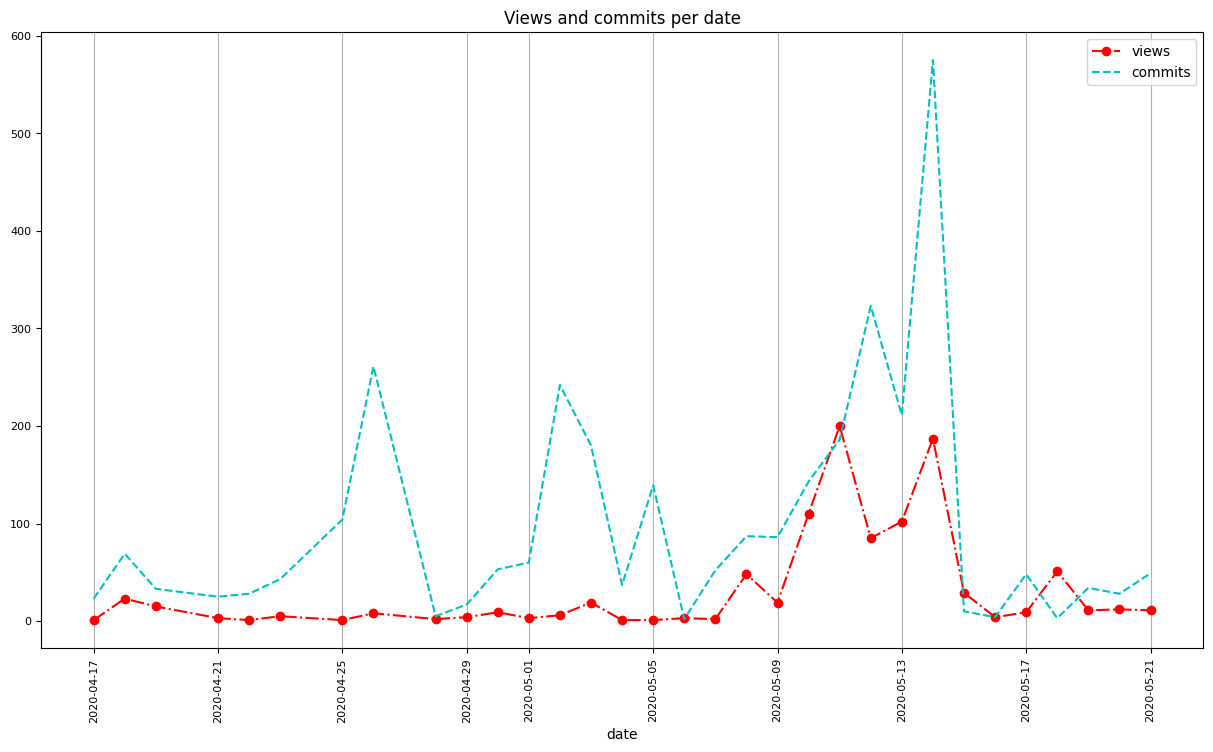

In [9]:
graph = df_result.plot(title="Views and commits per date", figsize=(15, 8), fontsize=8, rot=90, grid=True, style=["r-.o", "c--"])
graph.grid(axis="y")

_How many times was the number of views larger than 150?_ 
The answer is _2_

In [10]:
# проверка
print(f"The answer is {len(df_pageviews[df_pageviews['views'] > 150])}")


The answer is 2


In [11]:
connection.close()